In [1]:
from google.colab import files
import zipfile, os

uploaded = files.upload()

zip_path = "/content/image_super_resolution.zip"
extract_path = "/content/dataset"

for f in uploaded.keys():
    os.rename(f"/content/{f}", zip_path)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print(os.listdir(extract_path))

Saving image_super_resolution.zip to image_super_resolution.zip
['dataset']


In [3]:
import os

for dirpath, dirnames, filenames in os.walk("/content/dataset"):
    level = dirpath.replace("/content/dataset", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(dirpath)}/  ({len(filenames)} files)")
    if level >= 2:
        break

dataset/  (0 files)
  dataset/  (0 files)
    train/  (0 files)


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import save_image
from PIL import Image
import numpy as np
import os
import glob

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

SCALE_FACTOR = 4
HR_SIZE      = 128   # high-res crop size
LR_SIZE      = HR_SIZE // SCALE_FACTOR
BATCH_SIZE   = 8
EPOCHS       = 5

Device: cpu


In [7]:
class SRDataset(Dataset):
    def __init__(self, hr_dir):
        self.files = sorted(glob.glob(os.path.join(hr_dir, "**", "*.jpg"), recursive=True) +
                            glob.glob(os.path.join(hr_dir, "**", "*.png"), recursive=True))
        print(f"Found {len(self.files)} images in {hr_dir}")

        self.hr_transform = transforms.Compose([
            transforms.RandomCrop(HR_SIZE),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3),
        ])
        self.lr_transform = transforms.Compose([
            transforms.Resize(LR_SIZE, interpolation=Image.BICUBIC),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3),
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        # ensure image is large enough for crop
        if min(img.size) < HR_SIZE:
            img = img.resize((HR_SIZE, HR_SIZE), Image.BICUBIC)
        hr = self.hr_transform(img)
        # derive LR from HR
        hr_pil = transforms.ToPILImage()(hr * 0.5 + 0.5)
        lr = self.lr_transform(hr_pil)
        return lr, hr

# ---- adjust path if needed after checking Cell 2 output ----
TRAIN_DIR = "/content/dataset/dataset/train/high_res"

train_dataset = SRDataset(TRAIN_DIR)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                           shuffle=True, num_workers=2)
print("Batches per epoch:", len(train_loader))

Found 685 images in /content/dataset/dataset/train/high_res
Batches per epoch: 86


In [8]:
class GANGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1), nn.ReLU(True),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ReLU(True),
            # Upsample x2
            nn.Conv2d(64, 256, 3, 1, 1),
            nn.PixelShuffle(2), nn.ReLU(True),
            # Upsample x2 → total x4
            nn.Conv2d(64, 256, 3, 1, 1),
            nn.PixelShuffle(2), nn.ReLU(True),
            nn.Conv2d(64, 3, 3, 1, 1), nn.Tanh(),
        )
    def forward(self, x):
        return self.net(x)

# Discriminator: PatchGAN-style
class GANDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        def block(in_c, out_c, stride=2):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 4, stride, 1),
                nn.LeakyReLU(0.2, True)
            )
        self.net = nn.Sequential(
            block(3,  64, 2),
            block(64, 128, 2),
            block(128, 256, 2),
            block(256, 512, 2),
            nn.Conv2d(512, 1, 3, 1, 1),
        )
    def forward(self, x):
        return self.net(x)


In [9]:
class ResidualBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels),
            nn.PReLU(),
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.BatchNorm2d(channels),
        )
    def forward(self, x):
        return x + self.block(x)

class SRGANGenerator(nn.Module):
    def __init__(self, n_res=8):
        super().__init__()
        self.head = nn.Sequential(nn.Conv2d(3, 64, 9, 1, 4), nn.PReLU())
        self.res  = nn.Sequential(*[ResidualBlock(64) for _ in range(n_res)])
        self.mid  = nn.Sequential(nn.Conv2d(64, 64, 3, 1, 1), nn.BatchNorm2d(64))
        self.up   = nn.Sequential(
            nn.Conv2d(64, 256, 3, 1, 1), nn.PixelShuffle(2), nn.PReLU(),
            nn.Conv2d(64, 256, 3, 1, 1), nn.PixelShuffle(2), nn.PReLU(),
        )
        self.tail = nn.Conv2d(64, 3, 9, 1, 4)

    def forward(self, x):
        h = self.head(x)
        r = self.mid(self.res(h))
        return torch.tanh(self.tail(self.up(h + r)))

class SRGANDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        def block(ic, oc, s=1):
            return nn.Sequential(
                nn.Conv2d(ic, oc, 3, s, 1),
                nn.BatchNorm2d(oc),
                nn.LeakyReLU(0.2, True)
            )
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1), nn.LeakyReLU(0.2, True),
            block(64,  64,  2),
            block(64,  128, 1), block(128, 128, 2),
            block(128, 256, 1), block(256, 256, 2),
            block(256, 512, 1), block(512, 512, 2),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 1024), nn.LeakyReLU(0.2, True),
            nn.Linear(1024, 1),
        )
    def forward(self, x):
        return self.net(x)

In [10]:
# Dense Block used in RRDB
class DenseBlock(nn.Module):
    def __init__(self, channels=64, growth=32):
        super().__init__()
        self.c1 = nn.Conv2d(channels,          growth, 3, 1, 1)
        self.c2 = nn.Conv2d(channels+growth,   growth, 3, 1, 1)
        self.c3 = nn.Conv2d(channels+2*growth, growth, 3, 1, 1)
        self.c4 = nn.Conv2d(channels+3*growth, growth, 3, 1, 1)
        self.c5 = nn.Conv2d(channels+4*growth, channels, 3, 1, 1)
        self.act = nn.LeakyReLU(0.2, True)

    def forward(self, x):
        x1 = self.act(self.c1(x))
        x2 = self.act(self.c2(torch.cat([x, x1], 1)))
        x3 = self.act(self.c3(torch.cat([x, x1, x2], 1)))
        x4 = self.act(self.c4(torch.cat([x, x1, x2, x3], 1)))
        x5 = self.c5(torch.cat([x, x1, x2, x3, x4], 1))
        return x5 * 0.2 + x

class RRDB(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.db1 = DenseBlock(channels)
        self.db2 = DenseBlock(channels)
        self.db3 = DenseBlock(channels)
    def forward(self, x):
        return self.db3(self.db2(self.db1(x))) * 0.2 + x

class ESRGANGenerator(nn.Module):
    def __init__(self, n_rrdb=4):   # keep small for Colab CPU
        super().__init__()
        self.head = nn.Conv2d(3, 64, 3, 1, 1)
        self.body = nn.Sequential(*[RRDB(64) for _ in range(n_rrdb)])
        self.mid  = nn.Conv2d(64, 64, 3, 1, 1)
        self.up   = nn.Sequential(
            nn.Conv2d(64, 256, 3, 1, 1), nn.PixelShuffle(2), nn.LeakyReLU(0.2, True),
            nn.Conv2d(64, 256, 3, 1, 1), nn.PixelShuffle(2), nn.LeakyReLU(0.2, True),
        )
        self.tail = nn.Sequential(
            nn.Conv2d(64, 64, 3, 1, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(64, 3,  3, 1, 1),
        )
    def forward(self, x):
        h = self.head(x)
        return torch.tanh(self.tail(self.up(self.mid(self.body(h)) + h)))

# ESRGAN uses same discriminator style as SRGAN
ESRGANDiscriminator = SRGANDiscriminator



In [11]:
ESRGANDiscriminator = SRGANDiscriminator

In [12]:
from torchvision.models import vgg19, VGG19_Weights

def get_vgg_feature_extractor():
    vgg = vgg19(weights=VGG19_Weights.DEFAULT).features[:18].to(device).eval()
    for p in vgg.parameters():
        p.requires_grad = False
    return vgg

def perceptual_loss(vgg, sr, hr):
    return nn.functional.mse_loss(vgg(sr), vgg(hr))

def train_sr_model(name, generator, discriminator,
                   train_loader, epochs=EPOCHS,
                   use_perceptual=False):
    print(f"\n{'='*50}")
    print(f"  Training {name}")
    print(f"{'='*50}")

    gen  = generator.to(device)
    disc = discriminator.to(device)

    opt_g = optim.Adam(gen.parameters(),  lr=1e-4, betas=(0.9, 0.999))
    opt_d = optim.Adam(disc.parameters(), lr=1e-4, betas=(0.9, 0.999))

    adv_loss = nn.BCEWithLogitsLoss()
    pix_loss = nn.MSELoss()
    vgg      = get_vgg_feature_extractor() if use_perceptual else None

    for epoch in range(epochs):
        gen.train(); disc.train()
        g_total = d_total = 0.0

        for i, (lr_imgs, hr_imgs) in enumerate(train_loader):
            lr_imgs = lr_imgs.to(device)
            hr_imgs = hr_imgs.to(device)

            # ---- Discriminator ----
            sr_imgs = gen(lr_imgs).detach()
            real_pred = disc(hr_imgs)
            fake_pred = disc(sr_imgs)

            real_labels = torch.ones_like(real_pred)
            fake_labels = torch.zeros_like(fake_pred)

            d_loss = (adv_loss(real_pred, real_labels) +
                      adv_loss(fake_pred, fake_labels)) / 2

            opt_d.zero_grad(); d_loss.backward(); opt_d.step()

            # ---- Generator ----
            sr_imgs   = gen(lr_imgs)
            fake_pred = disc(sr_imgs)

            g_adv  = adv_loss(fake_pred, torch.ones_like(fake_pred))
            g_pix  = pix_loss(sr_imgs, hr_imgs)
            g_perc = perceptual_loss(vgg, sr_imgs, hr_imgs) if use_perceptual else 0

            g_loss = g_adv * 0.001 + g_pix + (g_perc * 0.006 if use_perceptual else 0)

            opt_g.zero_grad(); g_loss.backward(); opt_g.step()

            g_total += g_loss.item()
            d_total += d_loss.item()

            if (i + 1) % 20 == 0:
                print(f"  Epoch [{epoch+1}/{epochs}] Step [{i+1}/{len(train_loader)}] "
                      f"G: {g_loss.item():.4f}  D: {d_loss.item():.4f}")

        print(f"Epoch [{epoch+1}/{epochs}] Avg G Loss: {g_total/len(train_loader):.4f} | "
              f"Avg D Loss: {d_total/len(train_loader):.4f}")

    return gen

In [13]:
gan_gen = train_sr_model(
    "Basic GAN",
    GANGenerator(),
    GANDiscriminator(),
    train_loader,
    epochs=EPOCHS,
    use_perceptual=False
)


  Training Basic GAN
  Epoch [1/5] Step [20/86] G: 0.2606  D: 0.2457
  Epoch [1/5] Step [40/86] G: 0.1199  D: 0.2272
  Epoch [1/5] Step [60/86] G: 0.1122  D: 0.5655
  Epoch [1/5] Step [80/86] G: 0.0825  D: 0.5358
Epoch [1/5] Avg G Loss: 0.1724 | Avg D Loss: 0.5168
  Epoch [2/5] Step [20/86] G: 0.0506  D: 0.6584
  Epoch [2/5] Step [40/86] G: 0.0502  D: 0.6350
  Epoch [2/5] Step [60/86] G: 0.0602  D: 0.5998
  Epoch [2/5] Step [80/86] G: 0.0455  D: 0.6489
Epoch [2/5] Avg G Loss: 0.0522 | Avg D Loss: 0.6166
  Epoch [3/5] Step [20/86] G: 0.0349  D: 0.6141
  Epoch [3/5] Step [40/86] G: 0.0289  D: 0.6155
  Epoch [3/5] Step [60/86] G: 0.0325  D: 0.6114
  Epoch [3/5] Step [80/86] G: 0.0293  D: 0.6100
Epoch [3/5] Avg G Loss: 0.0372 | Avg D Loss: 0.6014
  Epoch [4/5] Step [20/86] G: 0.0281  D: 0.6094
  Epoch [4/5] Step [40/86] G: 0.0384  D: 0.4539
  Epoch [4/5] Step [60/86] G: 0.0379  D: 0.4456
  Epoch [4/5] Step [80/86] G: 0.0312  D: 0.5103
Epoch [4/5] Avg G Loss: 0.0318 | Avg D Loss: 0.5310
  

In [14]:
srgan_gen = train_sr_model(
    "SRGAN",
    SRGANGenerator(),
    SRGANDiscriminator(),
    train_loader,
    epochs=EPOCHS,
    use_perceptual=True
)



  Training SRGAN
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:09<00:00, 61.9MB/s]


  Epoch [1/5] Step [20/86] G: 0.1707  D: 0.4978
  Epoch [1/5] Step [40/86] G: 0.0859  D: 0.7288
  Epoch [1/5] Step [60/86] G: 0.1024  D: 0.3248
  Epoch [1/5] Step [80/86] G: 0.0996  D: 0.2565
Epoch [1/5] Avg G Loss: 0.1440 | Avg D Loss: 0.4972
  Epoch [2/5] Step [20/86] G: 0.0829  D: 0.2010
  Epoch [2/5] Step [40/86] G: 0.0907  D: 0.1587
  Epoch [2/5] Step [60/86] G: 0.1182  D: 0.1517
  Epoch [2/5] Step [80/86] G: 0.0785  D: 0.7443
Epoch [2/5] Avg G Loss: 0.0884 | Avg D Loss: 0.4643
  Epoch [3/5] Step [20/86] G: 0.0839  D: 0.7032
  Epoch [3/5] Step [40/86] G: 0.0871  D: 0.6878
  Epoch [3/5] Step [60/86] G: 0.0660  D: 0.6784
  Epoch [3/5] Step [80/86] G: 0.0651  D: 0.6851
Epoch [3/5] Avg G Loss: 0.0717 | Avg D Loss: 0.6813
  Epoch [4/5] Step [20/86] G: 0.0854  D: 0.6183
  Epoch [4/5] Step [40/86] G: 0.0766  D: 0.6244
  Epoch [4/5] Step [60/86] G: 0.0710  D: 0.4579
  Epoch [4/5] Step [80/86] G: 0.0670  D: 0.7805
Epoch [4/5] Avg G Loss: 0.0650 | Avg D Loss: 0.5843
  Epoch [5/5] Step [20/8

In [15]:
esrgan_gen = train_sr_model(
    "ESRGAN",
    ESRGANGenerator(),
    ESRGANDiscriminator(),
    train_loader,
    epochs=EPOCHS,
    use_perceptual=True
)



  Training ESRGAN
  Epoch [1/5] Step [20/86] G: 0.2316  D: 0.4111
  Epoch [1/5] Step [40/86] G: 0.1035  D: 0.2315
  Epoch [1/5] Step [60/86] G: 0.1179  D: 0.1494
  Epoch [1/5] Step [80/86] G: 0.1008  D: 0.8465
Epoch [1/5] Avg G Loss: 0.1687 | Avg D Loss: 0.3715
  Epoch [2/5] Step [20/86] G: 0.1153  D: 0.5913
  Epoch [2/5] Step [40/86] G: 0.0694  D: 0.2989
  Epoch [2/5] Step [60/86] G: 0.0445  D: 0.2085
  Epoch [2/5] Step [80/86] G: 0.0909  D: 0.1686
Epoch [2/5] Avg G Loss: 0.0822 | Avg D Loss: 0.4973
  Epoch [3/5] Step [20/86] G: 0.0868  D: 0.1974
  Epoch [3/5] Step [40/86] G: 0.0687  D: 0.2183
  Epoch [3/5] Step [60/86] G: 0.0554  D: 0.1308
  Epoch [3/5] Step [80/86] G: 0.0830  D: 0.1104
Epoch [3/5] Avg G Loss: 0.0682 | Avg D Loss: 0.2091
  Epoch [4/5] Step [20/86] G: 0.0550  D: 0.3862
  Epoch [4/5] Step [40/86] G: 0.0723  D: 0.1647
  Epoch [4/5] Step [60/86] G: 0.0691  D: 0.1628
  Epoch [4/5] Step [80/86] G: 0.0608  D: 0.4392
Epoch [4/5] Avg G Loss: 0.0595 | Avg D Loss: 0.3325
  Epo

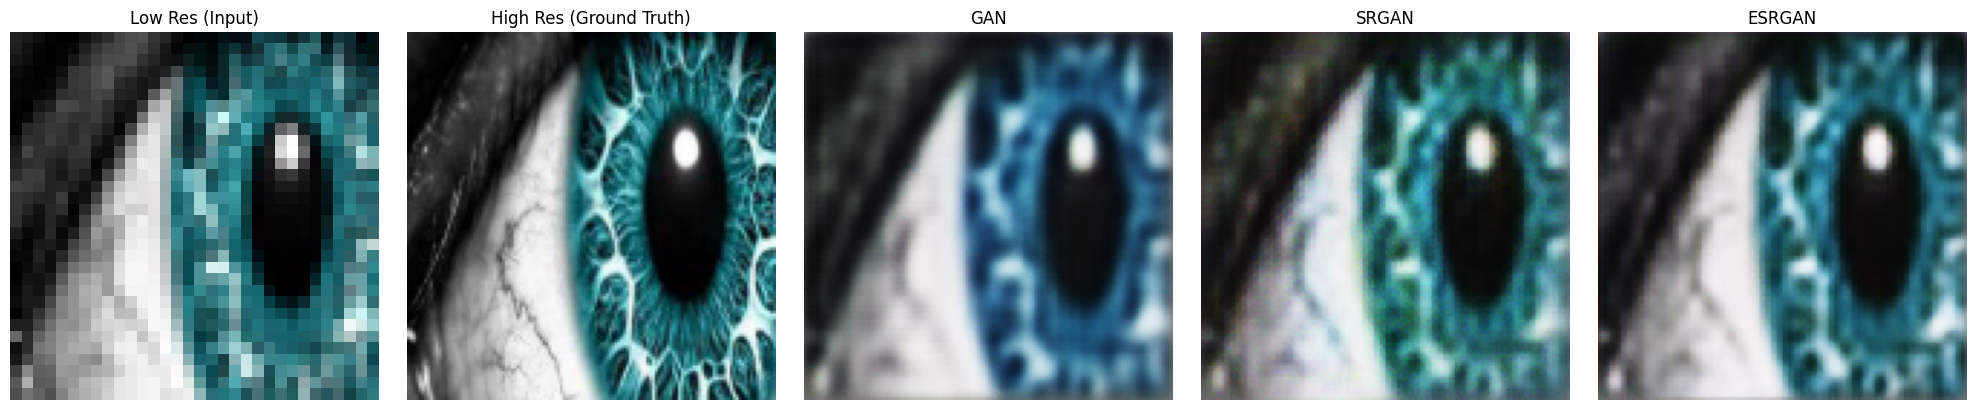

Saved comparison to /content/sr_comparison.png


In [16]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

def denorm(t):
    return (t * 0.5 + 0.5).clamp(0, 1)

def compare_models(lr_img, hr_img, models_dict):
    fig, axes = plt.subplots(1, len(models_dict) + 2, figsize=(4*(len(models_dict)+2), 4))

    axes[0].imshow(TF.to_pil_image(denorm(lr_img.squeeze(0).cpu())))
    axes[0].set_title("Low Res (Input)")
    axes[0].axis("off")

    axes[1].imshow(TF.to_pil_image(denorm(hr_img.squeeze(0).cpu())))
    axes[1].set_title("High Res (Ground Truth)")
    axes[1].axis("off")

    for ax, (name, model) in zip(axes[2:], models_dict.items()):
        model.eval()
        with torch.no_grad():
            sr = model(lr_img.to(device)).squeeze(0).cpu()
        axes[axes.tolist().index(ax)].imshow(TF.to_pil_image(denorm(sr)))
        ax.set_title(name)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("/content/sr_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved comparison to /content/sr_comparison.png")

# grab one sample
sample_lr, sample_hr = next(iter(train_loader))
compare_models(
    sample_lr[:1], sample_hr[:1],
    {"GAN": gan_gen, "SRGAN": srgan_gen, "ESRGAN": esrgan_gen}
)

In [17]:
def psnr(sr, hr):
    mse = nn.functional.mse_loss(denorm(sr), denorm(hr))
    return 10 * torch.log10(1.0 / mse).item()

def evaluate_psnr(name, model, loader, n_batches=10):
    model.eval()
    scores = []
    with torch.no_grad():
        for i, (lr, hr) in enumerate(loader):
            if i >= n_batches:
                break
            sr = model(lr.to(device)).cpu()
            for s, h in zip(sr, hr):
                scores.append(psnr(s, h))
    avg = np.mean(scores)
    print(f"{name:12s} → Avg PSNR: {avg:.2f} dB")
    return avg

print("\n" + "="*40)
print("       PSNR COMPARISON")
print("="*40)
gan_psnr     = evaluate_psnr("GAN",     gan_gen,     train_loader)
srgan_psnr   = evaluate_psnr("SRGAN",   srgan_gen,   train_loader)
esrgan_psnr  = evaluate_psnr("ESRGAN",  esrgan_gen,  train_loader)

print("="*40)
print(f"  Best model: "
      f"{'GAN' if gan_psnr>=srgan_psnr and gan_psnr>=esrgan_psnr else 'SRGAN' if srgan_psnr>=esrgan_psnr else 'ESRGAN'}")
print("="*40)



       PSNR COMPARISON
GAN          → Avg PSNR: 22.67 dB
SRGAN        → Avg PSNR: 23.17 dB
ESRGAN       → Avg PSNR: 24.27 dB
  Best model: ESRGAN
